# Volatility Models: Realized vs Conditional Approaches

This notebook compares two fundamentally different approaches to measuring volatility:

1. **Realized volatility estimators**: backward-looking, computed from observed prices
2. **Conditional volatility models**: forward-looking, estimated from GARCH-family models

We examine three realized vol estimators (close-to-close, Parkinson, Garman-Klass), compare them against GARCH and GJR-GARCH conditional volatility, and analyze the volatility of volatility.

**Data:** SPY daily OHLC prices, January 2019 - December 2024.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os
os.makedirs('figures', exist_ok=True)

spy = yf.download('SPY', start='2019-01-01', end='2025-01-01')
spy.columns = spy.columns.get_level_values(0)
spy['Return'] = 100 * spy['Close'].pct_change()
spy = spy.dropna()

print(f"Period: {spy.index[0].date()} to {spy.index[-1].date()}")
print(f"Observations: {len(spy)}")

[*********************100%***********************]  1 of 1 completed

Period: 2019-01-03 to 2024-12-31
Observations: 1509


## 1. Realized Volatility Estimators

Realized volatility is estimated directly from observed price data. The simplest approach uses closing prices only. More sophisticated estimators incorporate intraday range information (high, low, open) to produce more statistically efficient estimates.

### 1.1 Close-to-Close (Standard)

The most common estimator. Rolling standard deviation of log returns over a fixed window.

$$\hat{\sigma}_{CC} = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (r_i - \bar{r})^2}$$

Simple but inefficient: it ignores all intraday price movement.

### 1.2 Parkinson (1980)

Uses the daily high-low range. Under GBM assumptions, the range is a more efficient estimator of volatility than close-to-close returns.

$$\hat{\sigma}_{P}^2 = \frac{1}{4 \ln 2} (\ln H_t - \ln L_t)^2$$

Theoretically ~5x more efficient than close-to-close. Biased downward when prices gap overnight.

### 1.3 Garman-Klass (1980)

Uses open, high, low, and close. Combines the range estimator with the close-to-open return for maximum efficiency under GBM.

$$\hat{\sigma}_{GK}^2 = 0.5 (\ln H_t - \ln L_t)^2 - (2\ln 2 - 1)(\ln C_t - \ln O_t)^2$$

Most efficient of the three for daily data. Standard in practice for realized vol estimation.

In [2]:
returns_decimal = spy['Return'] / 100

# 1. Close-to-close: rolling std of returns at different windows
spy['RV_CC_21'] = returns_decimal.rolling(window=21).std()
spy['RV_CC_5'] = returns_decimal.rolling(window=5).std()
spy['RV_CC_63'] = returns_decimal.rolling(window=63).std()

# 2. Parkinson: high-low range estimator
spy['Parkinson'] = np.sqrt(
    (1 / (4 * np.log(2))) * (np.log(spy['High'] / spy['Low'])) ** 2
)
spy['RV_Park_21'] = spy['Parkinson'].rolling(window=21).mean()

# 3. Garman-Klass: open, high, low, close estimator
spy['GK'] = (
    0.5 * (np.log(spy['High'] / spy['Low'])) ** 2
    - (2 * np.log(2) - 1) * (np.log(spy['Close'] / spy['Open'])) ** 2
)
spy['RV_GK_21'] = np.sqrt(spy['GK'].rolling(window=21).mean())

print("Realized Volatility Estimators (last 5 rows):")
print(spy[['RV_CC_21', 'RV_Park_21', 'RV_GK_21']].tail())

Realized Volatility Estimators (last 5 rows):
Price       RV_CC_21  RV_Park_21  RV_GK_21
Date                                      
2024-12-24  0.008589    0.005058  0.006082
2024-12-26  0.008567    0.004997  0.006014
2024-12-27  0.008818    0.005179  0.006216
2024-12-30  0.009134    0.005365  0.006451
2024-12-31  0.009017    0.005479  0.006549


## 2. Realized Volatility Comparison

### 2.1 Estimator Comparison (21-day window)

All three estimators use a 21-day rolling window (~1 month). They should track each other closely but differ in smoothness due to efficiency differences. Parkinson and Garman-Klass use more information per observation, producing less noisy estimates.

### 2.2 Window Length Comparison (Close-to-Close)

The choice of window length reflects a bias-variance tradeoff:
- **5-day**: highly responsive to recent moves, but noisy
- **21-day**: standard monthly estimate, balances responsiveness and stability
- **63-day**: quarterly estimate, smooth but slow to react to regime changes

For vol trading, the relevant window depends on the horizon of the trade.

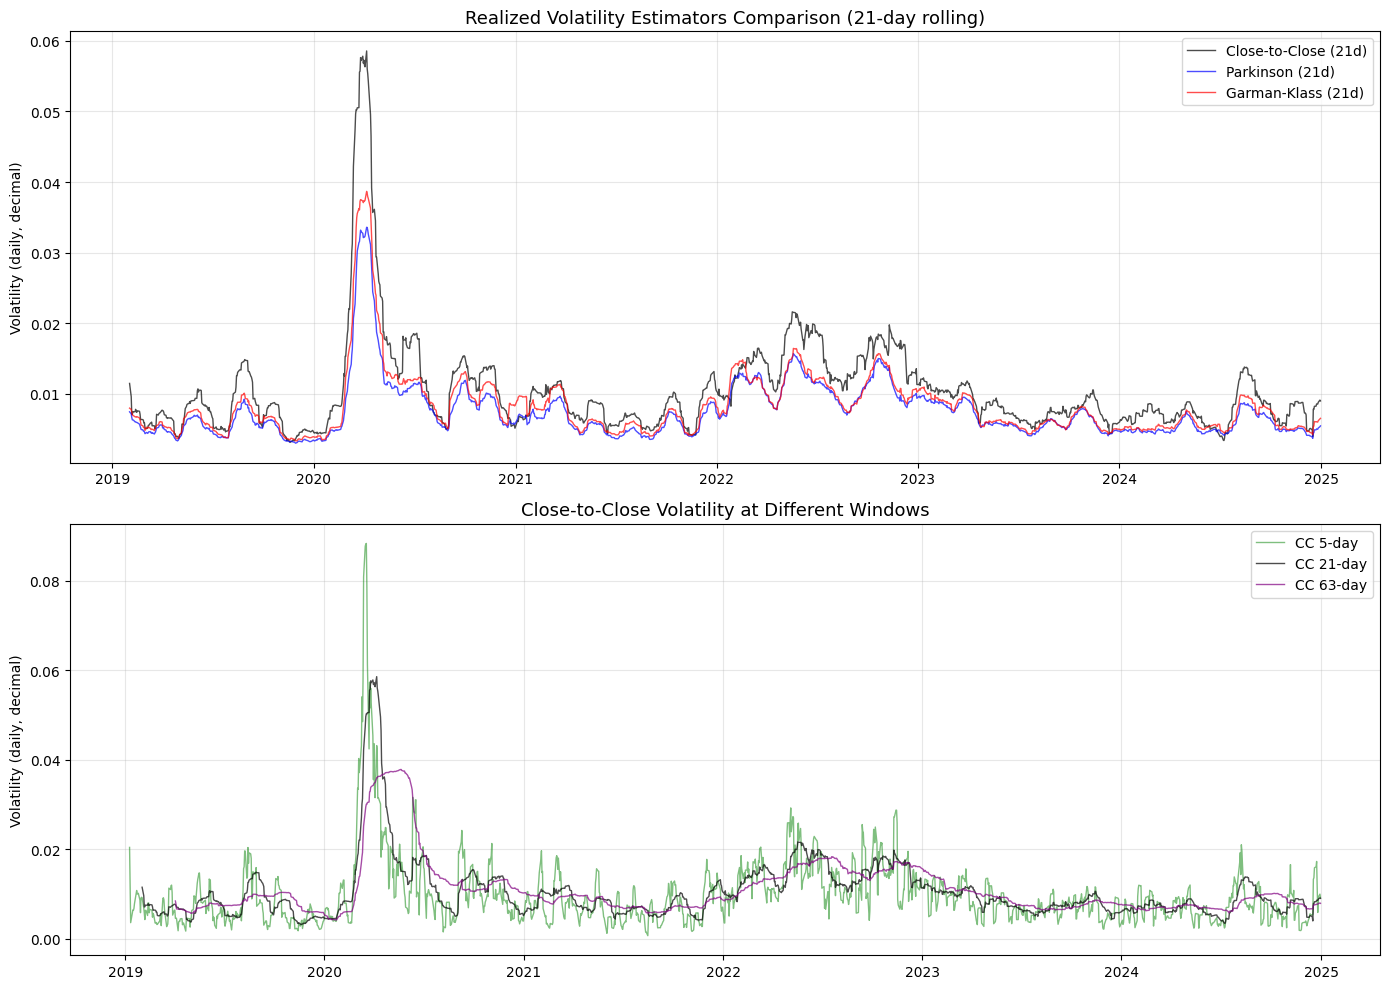

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top panel: all three estimators, 21-day window
axes[0].plot(spy.index, spy['RV_CC_21'], color='black', alpha=0.7, linewidth=1, label='Close-to-Close (21d)')
axes[0].plot(spy.index, spy['RV_Park_21'], color='blue', alpha=0.7, linewidth=1, label='Parkinson (21d)')
axes[0].plot(spy.index, spy['RV_GK_21'], color='red', alpha=0.7, linewidth=1, label='Garman-Klass (21d)')
axes[0].set_title('Realized Volatility Estimators Comparison (21-day rolling)', fontsize=13)
axes[0].set_ylabel('Volatility (daily, decimal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom panel: close-to-close at different windows
axes[1].plot(spy.index, spy['RV_CC_5'], color='green', alpha=0.5, linewidth=1, label='CC 5-day')
axes[1].plot(spy.index, spy['RV_CC_21'], color='black', alpha=0.7, linewidth=1, label='CC 21-day')
axes[1].plot(spy.index, spy['RV_CC_63'], color='purple', alpha=0.7, linewidth=1, label='CC 63-day')
axes[1].set_title('Close-to-Close Volatility at Different Windows', fontsize=13)
axes[1].set_ylabel('Volatility (daily, decimal)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/realized_vol_comparison.png', dpi=150)
plt.show()

## 3. Conditional vs Realized Volatility

Conditional volatility (from GARCH models) is a **one-step-ahead forecast** updated daily based on the model's parameters and yesterday's information. Realized volatility is a **backward-looking estimate** computed over a rolling window.

Key differences:
- GARCH responds to shocks immediately (single day). Realized vol needs the full window to reflect the change.
- GARCH should **lead** realized vol during volatility spikes and **lag** during calm periods.
- GARCH is model-dependent. Realized vol is model-free.

The gap between the two is informative: when GARCH conditional vol is significantly above realized vol, the model is forecasting elevated risk that hasn't fully materialized in the rolling window yet.

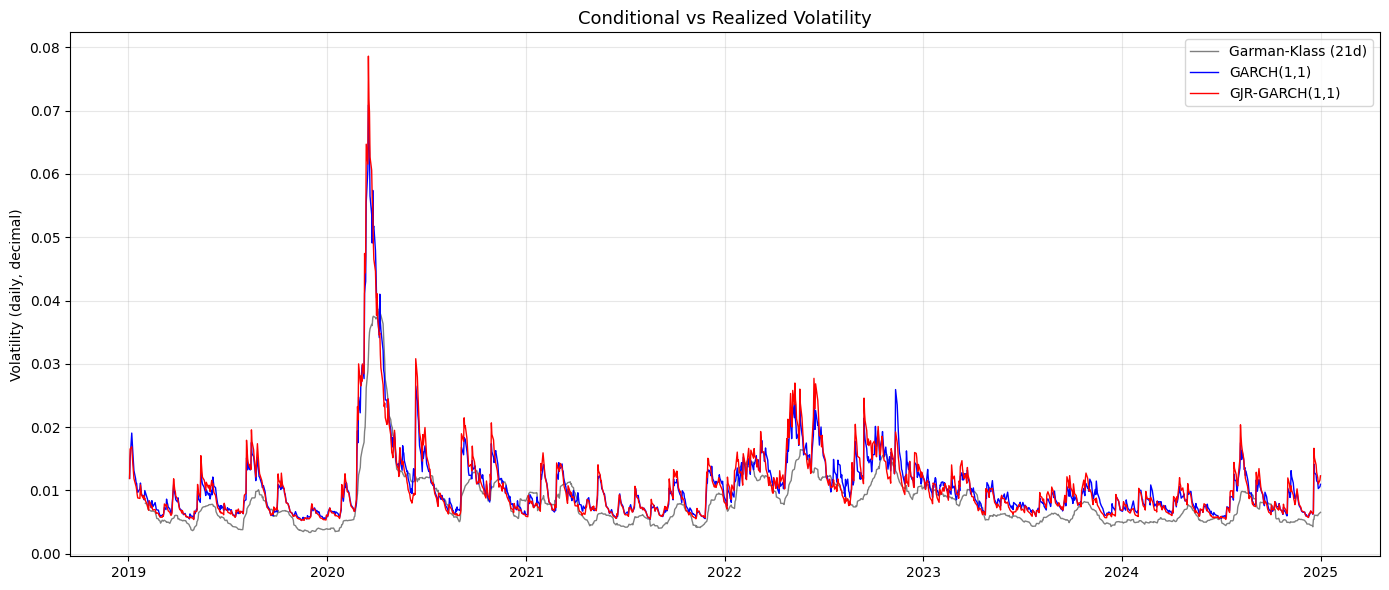

In [4]:
from arch import arch_model

# Fit GARCH(1,1) and GJR-GARCH(1,1) on full sample
garch = arch_model(spy['Return'], vol='GARCH', p=1, q=1, mean='Constant')
garch_fit = garch.fit(disp='off')

gjr = arch_model(spy['Return'], vol='GARCH', p=1, o=1, q=1, mean='Constant')
gjr_fit = gjr.fit(disp='off')

# Extract conditional vol in decimal scale
spy['GARCH_vol'] = garch_fit.conditional_volatility / 100
spy['GJR_vol'] = gjr_fit.conditional_volatility / 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(spy.index, spy['RV_GK_21'], color='black', alpha=0.5, linewidth=1, label='Garman-Klass (21d)')
ax.plot(spy.index, spy['GARCH_vol'], color='blue', linewidth=1, label='GARCH(1,1)')
ax.plot(spy.index, spy['GJR_vol'], color='red', linewidth=1, label='GJR-GARCH(1,1)')
ax.set_title('Conditional vs Realized Volatility', fontsize=13)
ax.set_ylabel('Volatility (daily, decimal)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/conditional_vs_realized.png', dpi=150)
plt.show()

## 4. Correlation Between Estimators

How closely do the different volatility measures track each other?

- Realized estimators (CC, Parkinson, GK) should be highly correlated (0.95+) since they're all measuring the same underlying quantity with different levels of efficiency.
- GARCH conditional vol should be correlated but lower (~0.80-0.90) because it's a forecast, not a contemporaneous estimate.
- Divergence between conditional and realized vol is where trading signals live.

In [5]:
vol_cols = ['RV_CC_21', 'RV_Park_21', 'RV_GK_21', 'GARCH_vol', 'GJR_vol']
corr_matrix = spy[vol_cols].dropna().corr()

print("Correlation Matrix:")
print(corr_matrix.round(3))

Correlation Matrix:
Price       RV_CC_21  RV_Park_21  RV_GK_21  GARCH_vol  GJR_vol
Price                                                         
RV_CC_21       1.000       0.967     0.967      0.912    0.859
RV_Park_21     0.967       1.000     0.992      0.864    0.807
RV_GK_21       0.967       0.992     1.000      0.875    0.820
GARCH_vol      0.912       0.864     0.875      1.000    0.981
GJR_vol        0.859       0.807     0.820      0.981    1.000


## 5. Volatility of Volatility

Volatility itself is not constant. The variability of volatility over time (vol of vol) is what motivates stochastic volatility models like Heston.

Key observations:
- Vol of vol spikes during crises (COVID March 2020, 2022 rate hiking cycle) and compresses during calm regimes.
- High vol-of-vol periods correspond to when GARCH persistence matters most: the conditional variance is moving rapidly and mean-reverting dynamics dominate.
- In the Heston model, the parameter $\xi$ (vol of vol) controls this behavior directly. In GARCH, it emerges implicitly from the interaction of $\alpha$ (shock sensitivity) and $\beta$ (persistence).

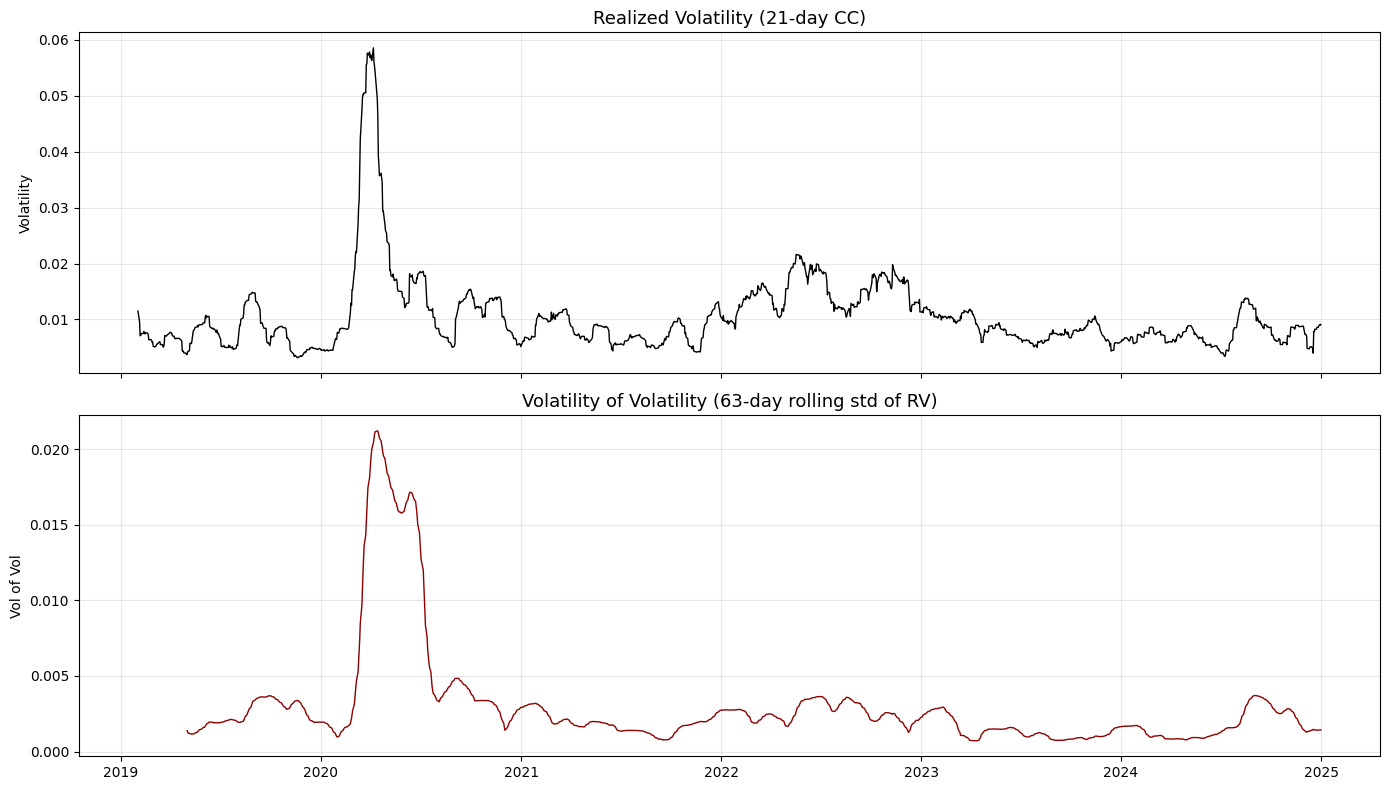

In [6]:
spy['vol_of_vol'] = spy['RV_CC_21'].rolling(window=63).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(spy.index, spy['RV_CC_21'], color='black', linewidth=1)
axes[0].set_title('Realized Volatility (21-day CC)', fontsize=13)
axes[0].set_ylabel('Volatility')
axes[0].grid(True, alpha=0.3)

axes[1].plot(spy.index, spy['vol_of_vol'], color='darkred', linewidth=1)
axes[1].set_title('Volatility of Volatility (63-day rolling std of RV)', fontsize=13)
axes[1].set_ylabel('Vol of Vol')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/vol_of_vol.png', dpi=150)
plt.show()

## Key Takeaways

1. **Realized vol estimators** differ in statistical efficiency. Garman-Klass dominates close-to-close for daily data by incorporating OHLC information.
2. **Window length** is a bias-variance tradeoff. Short windows are responsive but noisy. Long windows are smooth but laggy.
3. **GARCH conditional vol leads realized vol** during volatility spikes because it updates daily from a single observation, while realized vol requires the full rolling window to catch up.
4. **Vol of vol** is not constant. It clusters in time, spikes during crises, and compresses during calm markets. This is the empirical motivation for stochastic volatility models.
5. **The gap between conditional and realized vol** is where trading edge lives. A better volatility forecast than what the market implies is the foundation of vol trading.